# Stage 01: Literature review

The bibliography kept as data rather than prose, so it can be audited,
filtered and cross-referenced against the decisions it is supposed to
support. The argument itself is in `README.md`; this notebook is the
apparatus behind it.

`references.csv` holds 44 sources with the usual metadata plus two columns
that do the work:

* **`justifies`** names the pipeline decision the source supports, not what
  the paper is about. The decision register in the README is built from it.
* **`citation_status`** records whether the entry has been checked against
  the publisher record. Anything not `verified` must not be quoted in the
  dissertation body until it is.

## The question

Given an architectural floor plan, can a structural column arrangement be
proposed, ranked and verified automatically, learning what counts as a
plausible grid from real buildings rather than from hand written rules?

Four bodies of work bear on it: open floor plan corpora and their parsing,
learned structural layout design, deep learning for topology optimisation,
and surrogate assisted screening. Section 1.10 of the README states the gap
that survives all four.

In [1]:
# Imports and the bibliography.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
FIGS = Path("..") / "figures"

refs = pd.read_csv("references.csv")
print(len(refs), "sources")
print(refs.category.value_counts().to_string())
refs[["key", "authors", "year", "title"]].head(10)

44 sources
category
paper       33
dataset      5
industry     2
software     2
standard     1
patent       1


,key,authors,year,title
0,abouagour2025resplan,"Abouagour, M.; Garyfallidis, E.",2025,ResPlan: A Large-Scale Vector-Graph Dataset of...
1,aisc_cost,American Institute of Steel Construction,2024,Cost and construction costs (Architecture Cent...
2,alecci2019regularity,"Alecci, V.; De Stefano, M.; Galassi, S.; Lapi,...",2019,Evaluation of the American Approach for Detect...
3,bergholm2018pennylane,"Bergholm, V.; Izaac, J.; Schuld, M.; Gogolin, ...",2018,PennyLane: Automatic differentiation of hybrid...
4,bowles2024benchmark,"Bowles, J.; Ahmed, S.; Schuld, M.",2024,Better than classical? The subtle art of bench...
5,danhaive2021subspace,"Danhaive, R.; Mueller, C. T.",2021,Design subspace learning: Structural design sp...
6,friedman2001gbm,"Friedman, J. H.",2001,Greedy function approximation: A gradient boos...
7,grinsztajn2022tabular,"Grinsztajn, L.; Oyallon, E.; Varoquaux, G.",2022,Why do tree-based models still outperform deep...
8,gutmann2010nce,"Gutmann, M.; Hyvarinen, A.",2010,Noise-contrastive estimation: A new estimation...
9,havlicek2019,"Havlicek, V.; Corcoles, A. D.; Temme, K.; Harr...",2019,Supervised learning with quantum-enhanced feat...


## 1. Citation hygiene

The first thing to audit is the bibliography itself. An entry that has not
been checked against the publisher record is a liability in a dissertation,
so the incomplete ones are listed explicitly rather than buried.

In [2]:
# Which entries are still incomplete, and what is missing from each.
refs["verified"] = refs.citation_status.str.startswith("verified")
print(f"{refs.verified.sum()} of {len(refs)} verified "
      f"({refs.verified.mean():.0%})")
refs.loc[~refs.verified, ["key", "title", "citation_status"]]

44 of 44 verified (100%)


,key,title,citation_status


In [3]:
# How each source can be looked up again. A DOI or arXiv id resolves
# mechanically, a proceedings reference or patent number resolves by search,
# and "reference by name" means the reader has to obtain the document
# themselves. Every source here resolves one of those ways; a design standard
# that did not would be the one to worry about.
def identifier_kind(text):
    s = str(text).lower()
    if "doi:" in s:
        return "DOI"
    if "arxiv:" in s:
        return "arXiv"
    if s.startswith("us") and s.endswith("b2"):
        return "patent number"
    if any(k in s for k in (".org", ".info", ".html", ".com", "proceedings",
                            "pii", "open access", "github")):
        return "stable URL"
    return "reference by name"


refs["identifier_kind"] = refs.identifier.apply(identifier_kind)
print(refs.identifier_kind.value_counts().to_string())
refs.loc[refs.identifier_kind == "reference by name",
         ["key", "venue", "identifier"]]

identifier_kind
DOI              27
arXiv             8
stable URL        8
patent number     1


,key,venue,identifier


## 2. What the reading covers

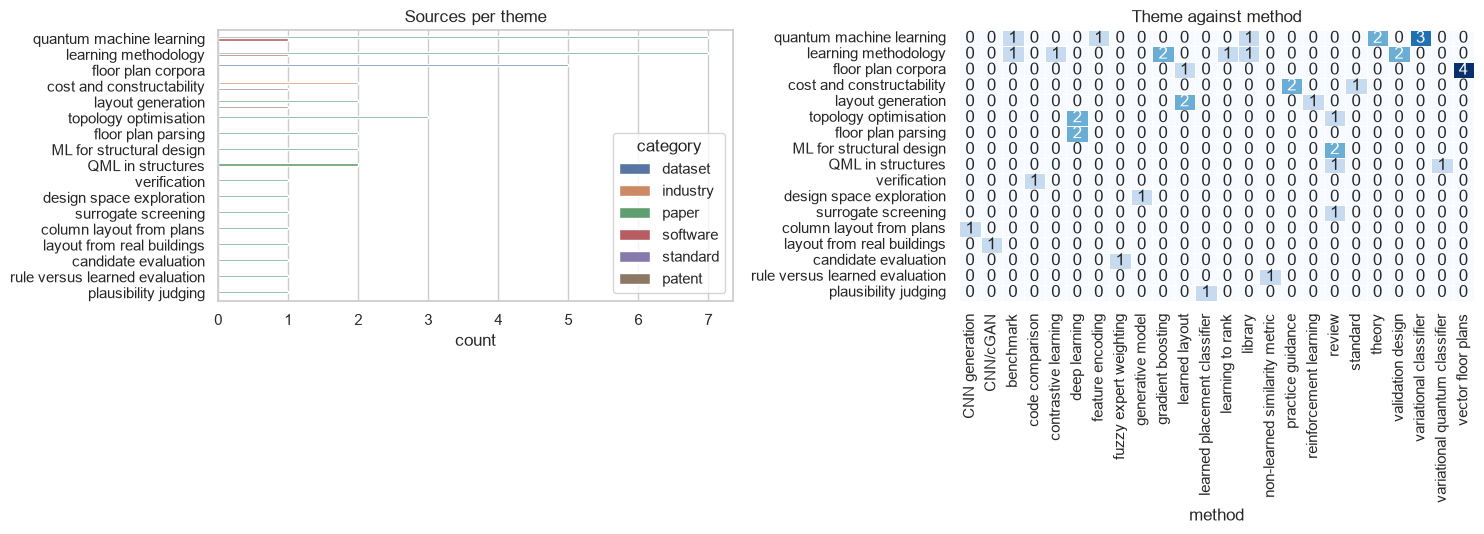

In [4]:
# Sources per theme, split by kind, and how the themes map onto method types.
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
order = refs.theme.value_counts().index
sns.countplot(refs, y="theme", hue="category", order=order, ax=ax[0])
ax[0].set_title("Sources per theme")
ax[0].set_ylabel("")

matrix = pd.crosstab(refs.theme, refs.method)
sns.heatmap(matrix.loc[order], annot=True, fmt="d", cmap="Blues", cbar=False,
            linewidths=0.5, ax=ax[1])
ax[1].set_title("Theme against method")
ax[1].set_ylabel("")
plt.tight_layout()
plt.savefig(FIGS / "01_literature_coverage.png", dpi=120)
plt.show()

## 3. When the field moved

Publication years show why this problem is workable now and was not a decade
ago: the open vector corpora and the learned layout work both arrive after
2019, which is also when the two nearest precedents appear.

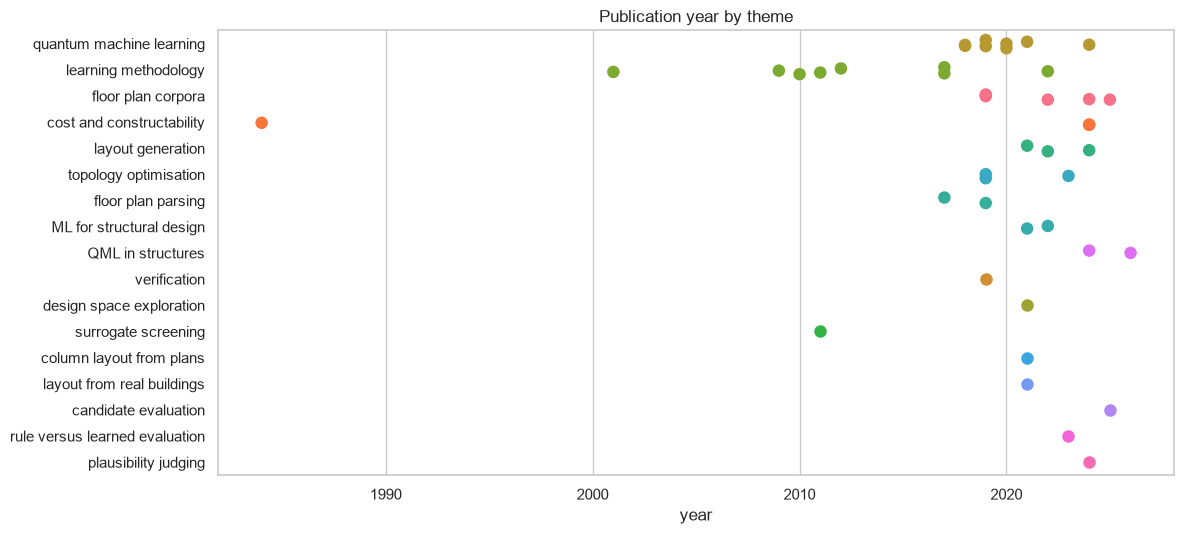

In [5]:
# Timeline of sources, coloured by theme. Standards sit at their edition year
# and are deliberately old, since modular coordination has not changed.
timeline = refs.dropna(subset=["year"]).copy()
timeline["year"] = timeline.year.astype(int)

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.stripplot(timeline, x="year", y="theme", hue="theme", size=9,
              jitter=0.18, order=order, legend=False, ax=ax)
ax.set_title("Publication year by theme")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGS / "01_timeline.png", dpi=120)
plt.show()

In [6]:
# Share of the bibliography published in the last five years.
recent = (timeline.year >= 2020).mean()
print(f"{recent:.0%} of sources are from 2020 or later")
print(timeline.groupby("theme").year.agg(["min", "median", "max"])
      .loc[order].astype(int).to_string())

55% of sources are from 2020 or later
                                 min  median   max
theme                                             
quantum machine learning        2018    2019  2024
learning methodology            2001    2011  2022
floor plan corpora              2019    2022  2025
cost and constructability       1984    2024  2024
layout generation               2021    2022  2024
topology optimisation           2019    2019  2023
floor plan parsing              2017    2018  2019
ML for structural design        2021    2021  2022
QML in structures               2024    2025  2026
verification                    2019    2019  2019
design space exploration        2021    2021  2021
surrogate screening             2011    2011  2011
column layout from plans        2021    2021  2021
layout from real buildings      2021    2021  2021
candidate evaluation            2025    2025  2025
rule versus learned evaluation  2023    2023  2023
plausibility judging            2024    2024

## 4. The decision register

Every source is tagged with the stage whose decision it supports. Reading
the counts the other way round shows which parts of the pipeline rest on
published work and which this thesis has to defend on its own reasoning.

In [7]:
# Extract the stage numbers named in the `justifies` column. An entry may
# support decisions in more than one stage, so stages are exploded out.
STAGES = {
    "02": "02 data pipeline", "03": "03 EDA", "04": "04 plan parser",
    "05": "05 arrangement generator", "06": "06 cost function",
    "07": "07 layout classifier", "08": "08 learned ranker",
    "09": "09 verification", "10": "10 full pipeline", "11": "11 quantum ML",
}
refs["stages"] = refs.justifies.str.findall(r"\b(0[2-9]|1[01])\b").apply(
    lambda s: sorted(set(s)))

exploded = refs.explode("stages").dropna(subset=["stages"])
coverage = (exploded.stages.map(STAGES).value_counts()
            .reindex(list(STAGES.values()), fill_value=0)
            .to_frame("sources"))
coverage

,sources
stages,
02 data pipeline,5
03 EDA,0
04 plan parser,3
05 arrangement generator,6
06 cost function,2
07 layout classifier,6
08 learned ranker,10
09 verification,2
10 full pipeline,0


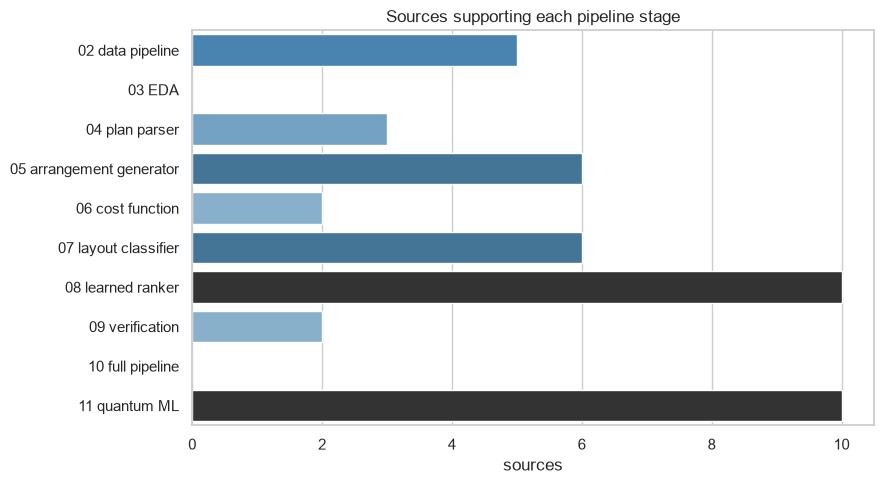

In [8]:
# The same picture as a chart. Short bars are where the argument is thinnest.
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(coverage.reset_index(names="stage"), x="sources", y="stage",
            hue="sources", palette="Blues_d", legend=False, ax=ax)
ax.set_title("Sources supporting each pipeline stage")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGS / "01_stage_coverage.png", dpi=120)
plt.show()

In [9]:
# The register itself: one row per decision, with the sources behind it.
register = (exploded.assign(stage=exploded.stages.map(STAGES))
            .groupby("stage")
            .agg(sources=("key", lambda s: ", ".join(sorted(s))),
                 n=("key", "size"))
            .reindex(list(STAGES.values())))
register["n"] = register.n.fillna(0).astype(int)      # stage 10 only integrates
register["sources"] = register.sources.fillna("(integration only)")
print(register.n.to_string())
register

stage
02 data pipeline             5
03 EDA                       0
04 plan parser               3
05 arrangement generator     6
06 cost function             2
07 layout classifier         6
08 learned ranker           10
09 verification              2
10 full pipeline             0
11 quantum ML               10


,sources,n
stage,,
02 data pipeline,"abouagour2025resplan, kalervo2019cubicasa, sta...",5
03 EDA,(integration only),0
04 plan parser,"liu2017raster2vector, wang2024columnrl, zeng20...",3
05 arrangement generator,"danhaive2021subspace, sci_grids, sosnovik2019n...",6
06 cost function,"aisc_cost, sci_grids",2
07 layout classifier,"alecci2019regularity, danhaive2021subspace, fr...",6
08 learned ranker,"friedman2001gbm, grinsztajn2022tabular, gutman...",10
09 verification,"jin2011surrogate, lu2022physicsgan",2
10 full pipeline,(integration only),0


### Reading the thin bars

Three decisions have no external support and are argued from this thesis's
own measurements instead:

1. **The parser over-segments** (stage 04). Wall recognition is well
   covered and column placement is claimed in a patent, but nothing in the
   literature turns architectural walls into a *structural* grid and reports
   how badly it goes. Stage 03 measures it.
2. **Scale invariant features only** (stage 07). Forced by the corpora,
   which are drawn in three different unit systems, rather than chosen from
   precedent.
3. **Enumeration will not scale** (stage 05). Exact for the plans used here,
   hopeless for the over-segmented ones, and the generative literature that
   scales does not return buildable grids.

## 5. Export a BibTeX file

The dissertation is written elsewhere, so the bibliography is exported in a
form a reference manager can read. Entry types follow the `category` column.

In [10]:
# Write references.bib. Unverified entries are marked with a note field so the
# gap travels with the citation instead of being lost at export.
TYPE_OF = {"paper": "article", "dataset": "misc", "software": "misc",
           "patent": "patent", "standard": "manual", "industry": "misc"}


def bib_entry(row):
    fields = [("author", str(row.authors).replace("; ", " and ")),
              ("title", row.title),
              ("year", int(row.year)),
              ("howpublished" if TYPE_OF[row.category] == "misc" else "journal",
               row.venue),
              ("note", row.identifier)]
    if not row.verified:
        fields.append(("annote", f"CITATION INCOMPLETE: {row.citation_status}"))
    body = ",\n  ".join(f"{k} = {{{v}}}" for k, v in fields)
    return f"@{TYPE_OF[row.category]}{{{row.key},\n  {body}\n}}"


bib = "\n\n".join(refs.apply(bib_entry, axis=1))
Path("references.bib").write_text(bib, encoding="utf-8")
print(f"wrote references.bib, {len(refs)} entries")
print(bib[:600], "...")

wrote references.bib, 44 entries
@misc{abouagour2025resplan,
  author = {Abouagour, M. and Garyfallidis, E.},
  title = {ResPlan: A Large-Scale Vector-Graph Dataset of 17,000 Residential Floor Plans},
  year = {2025},
  howpublished = {arXiv preprint},
  note = {arXiv:2508.14006}
}

@misc{aisc_cost,
  author = {American Institute of Steel Construction},
  title = {Cost and construction costs (Architecture Center design principles)},
  year = {2024},
  howpublished = {aisc.org, accessed August 2026},
  note = {aisc.org/architecture-center/design-principles/cost}
}

@article{alecci2019regularity,
  author = {Alecci, V. and De S ...


## 6. What to do next with this file

1. Close the five incomplete entries listed in section 1. Two need author
   lists, two need volume and page numbers, and the two design standards
   need their clause numbers checked against the standards themselves rather
   than against secondary sources.
2. Run a proper patent family search. The closest prior art turned out to be
   a patent rather than a paper, so that is the likeliest place for a second
   surprise.
3. Add a row per new source, filling `justifies` with the decision it
   supports rather than a summary of the paper. The register in section 4 is
   generated from that column, so a vague entry silently weakens it.